In [251]:
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [241]:
# assume DOM

In [252]:
prop_gens = 4
nworms = 20

In [253]:
df = pd.DataFrame(columns=['het','hom+','hom-', 'sum'])

In [254]:
def prop_onegen(geno_dist, nworms):
    pop_dist = {'het': 0, 'hom-': 0, 'hom+': 0}
    nhet = int(nworms * geno_dist['het'])
    nhomm = int(nworms * geno_dist['hom-'])
    nhomp = int(nworms * geno_dist['hom+'])

    nhetprog = nhet * 250
    pop_dist['hom-'] += nhomm * 250
    pop_dist['hom+'] += nhomp * 250

    nworms = nworms * 250

    i = np.random.multinomial(nhetprog, [0.25, 0.5, 0.25])

    pop_dist['hom-'] += i[0]
    pop_dist['het'] += i[1]
    pop_dist['hom+'] += i[2]

    probhet = pop_dist['het'] / float(nworms)
    probhomp = pop_dist['hom+'] / float(nworms)
    probhomm = pop_dist['hom-'] / float(nworms)

    return {'het': probhet, 'hom-': probhomm, 'hom+': probhomp, 'sum':probhet + probhomp + probhomm}, nworms

In [255]:
for j in range(3):
    geno_dist = {'het': 0.5, 'hom-': 0.5, 'hom+': 0.0,'sum':1}
    nworms = 20
    for i in range(prop_gens):
        geno_dist, nworms = prop_onegen(geno_dist, nworms)
    df.loc[len(df)] = geno_dist

In [256]:
df.head()

,het,hom+,hom-,sum
0,0.032396,0.236897,0.730506,0.9998
1,0.030034,0.234341,0.735625,1.0000
2,0.030788,0.232000,0.737212,1.0000


/tmp/ipykernel_230/960648226.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df['het'], df['hom+'], df['hom-']], labels=['het', 'hom+', 'hom-'])


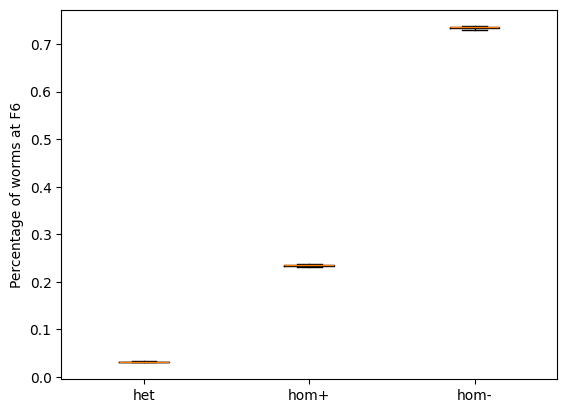

In [257]:
plt.boxplot([df['het'], df['hom+'], df['hom-']], labels=['het', 'hom+', 'hom-'])
plt.ylabel('Percentage of worms at F6')
plt.show()

In [258]:
np.var(df['het']), np.var(df['hom-']), np.var(df['hom+'])

(9.704306865142703e-07, 8.187413531044885e-06, 3.999760500691548e-06)